In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
Kuppe_Moran_df = pd.read_csv("../Kuppe_2022/analysis_scripts/Kuppe_Moran_I_results.csv", index_col=0)
Kuppe_Moran_df['study'] = "Kuppe 2022"

Kanemaru_Moran_df = pd.read_csv("../Kanemaru_2023/analysis_scripts/Kanemaru_Moran_I_results.csv", index_col=0)
Kanemaru_Moran_df['study'] = "Kanemaru 2023"

In [4]:
combined_df = pd.concat([Kuppe_Moran_df, Kanemaru_Moran_df])

In [10]:
plots_dir = "plots/"
os.makedirs(plots_dir, exist_ok=True)

### divide into disease

In [6]:
disease_groups = ["IZ", "IZ_BZ", "GT_IZ", "FZ", "FZ_GT"]

In [7]:
combined_df['diseased_region'] = "N"
combined_df.loc[combined_df['region'].isin(disease_groups), 'diseased_region'] = "Y"

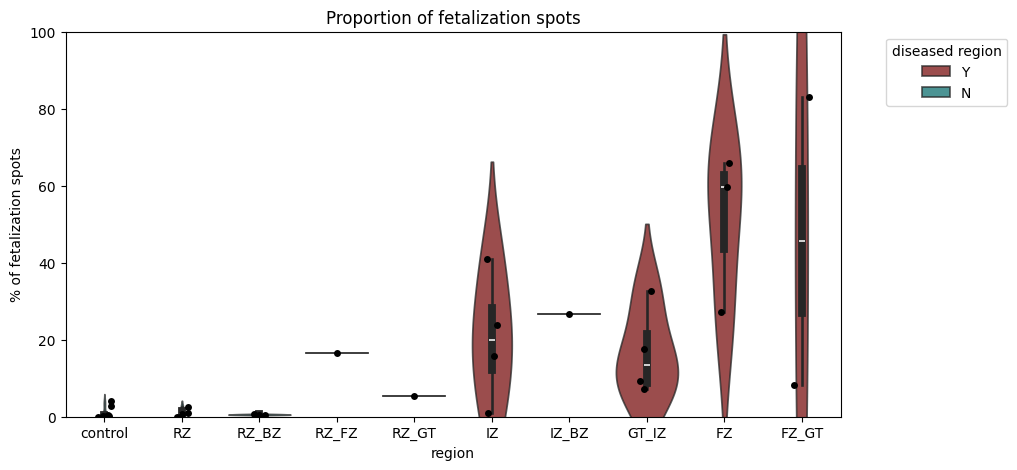

In [11]:
desired_order = ["control", "RZ", "RZ_BZ", "RZ_FZ", "RZ_GT", "IZ", "IZ_BZ", "GT_IZ", "FZ", "FZ_GT"]

color_palette = {"Y": "#8B0000", "N": "#008080"}

plt.figure(figsize = (10, 5))
sns.violinplot(data = combined_df, x = 'region', y = 'prop_fetalization_spots', 
               hue = 'diseased_region', order=desired_order, palette=color_palette, alpha = 0.75)
sns.stripplot(data = combined_df, x = 'region', y = 'prop_fetalization_spots', color = 'black')
plt.title("Proportion of fetalization spots")
plt.xlabel("region")
plt.ylim(0, 100)
plt.legend(title='diseased region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("% of fetalization spots")
plt.savefig(plots_dir + "percentage_of_fetalization_spots_across_spatial_regions.pdf")

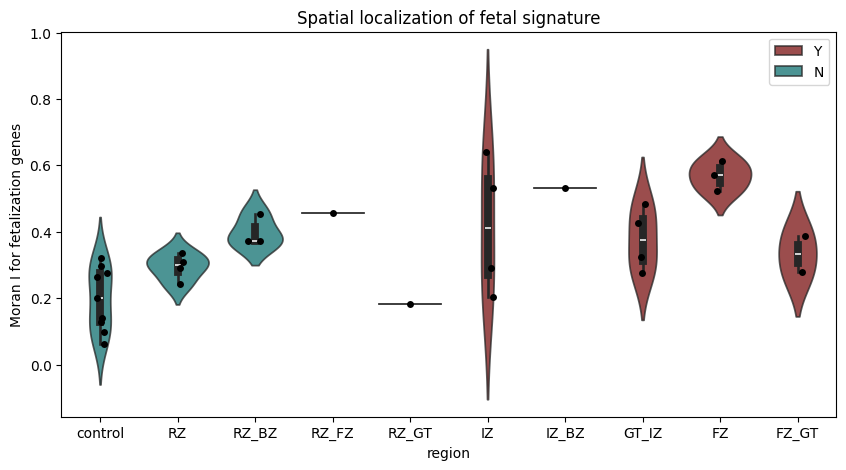

In [12]:
plt.figure(figsize = (10, 5))
sns.violinplot(data = combined_df, 
               x = 'region',
               y = 'fetal_Moran', 
               hue = 'diseased_region', 
               palette=color_palette, order=desired_order, alpha = 0.75)
sns.stripplot(data = combined_df, x = 'region', y = 'fetal_Moran', color = 'black')
plt.title("Spatial localization of fetal signature")
plt.xlabel("region")
plt.ylabel("Moran I for fetalization genes")
plt.savefig(plots_dir + "Moran_I_across_spatial_regions.pdf")

### Mann-Whitney for ND vs D of fetalization Moran's I

In [13]:
from scipy.stats import mannwhitneyu

ND_regions = ["control", "RZ", "RZ_BZ", "RZ_FZ", "RZ_GT"]
D_regions = ["FZ", "FZ_GT", "IZ", "IZ_BZ", "GT_IZ"]

ND_values = combined_df[combined_df["region"].isin(ND_regions)]["fetal_Moran"]
D_values = combined_df[combined_df["region"].isin(D_regions)]["fetal_Moran"]

stat, p_value = mannwhitneyu(ND_values, D_values, alternative="two-sided") 

print(f"p value for proportion of fetalization spots in diseased vs ND regions is: {p_value}")

p value for proportion of fetalization spots in diseased vs ND regions is: 0.003240193060158028


### Mann-Whitney for ND vs D of proportion of fetalization spots

In [14]:
ND_regions = ["control", "RZ", "RZ_BZ", "RZ_FZ", "RZ_GT"]
D_regions = ["FZ", "FZ_GT", "IZ", "IZ_BZ", "GT_IZ"]

ND_values = combined_df[combined_df["region"].isin(ND_regions)]["prop_fetalization_spots"]
D_values = combined_df[combined_df["region"].isin(D_regions)]["prop_fetalization_spots"]

stat, p_value = mannwhitneyu(ND_values, D_values, alternative="two-sided") 

print(f"p value for fetalization Moran's I in diseased vs. ND regions is: {p_value}")

p value for fetalization Moran's I in diseased vs. ND regions is: 1.1467037826363561e-05


In [15]:
combined_df.to_csv("combined_results.csv")